In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

BASE      = '/content/drive/MyDrive/customer-segmentation'
PROCESSED = f'{BASE}/data/processed'

print("Ready!")

Ready!


In [3]:
rfm        = pd.read_csv(f'{PROCESSED}/rfm.csv')
rfm_scaled = pd.read_csv(f'{PROCESSED}/rfm_scaled.csv')

print(f"RFM shape: {rfm.shape}")
print(f"Scaled shape: {rfm_scaled.shape}")
print(f"\nScaled sample:")
print(rfm_scaled.head())

RFM shape: (4338, 4)
Scaled shape: (4338, 3)

Scaled sample:
    Recency  Frequency  Monetary
0  1.461993  -0.955214  3.707710
1 -2.038734   1.074425  1.414899
2  0.373104   0.386304  0.720020
3 -0.623086  -0.955214  0.702283
4  1.424558  -0.955214 -0.614517


In [4]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    print(f"K={k} | Inertia: {kmeans.inertia_:.2f}")

K=1 | Inertia: 13014.00
K=2 | Inertia: 6483.56
K=3 | Inertia: 4869.48
K=4 | Inertia: 3939.07
K=5 | Inertia: 3296.69
K=6 | Inertia: 2855.76
K=7 | Inertia: 2548.80
K=8 | Inertia: 2336.32
K=9 | Inertia: 2155.98
K=10 | Inertia: 2005.39


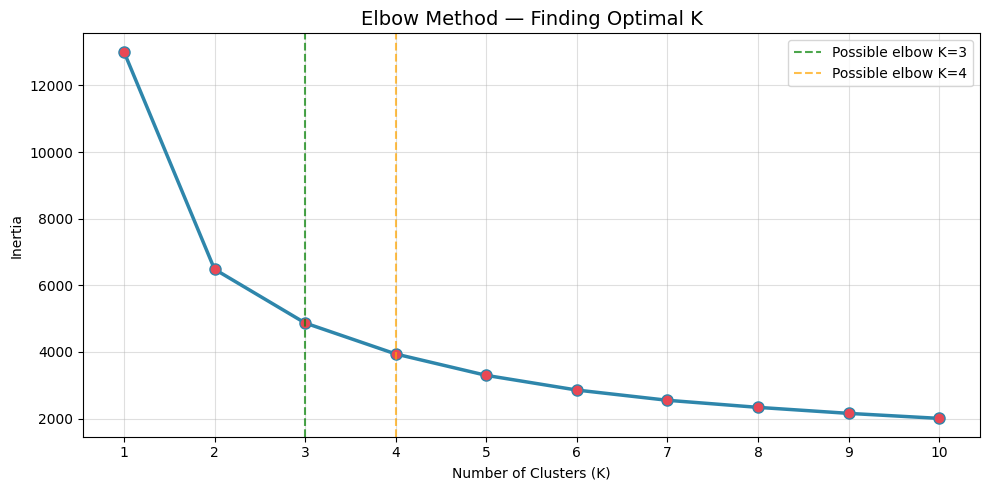

Plot saved!


In [5]:
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', linewidth=2.5,
         color='#2E86AB', markersize=8, markerfacecolor='#E84855')

plt.title('Elbow Method — Finding Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True, alpha=0.4)

# Mark the likely elbow
plt.axvline(x=3, color='green', linestyle='--', alpha=0.7, label='Possible elbow K=3')
plt.axvline(x=4, color='orange', linestyle='--', alpha=0.7, label='Possible elbow K=4')
plt.legend()

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/figures/elbow_curve.png', dpi=150)
plt.show()
print("Plot saved!")

In [6]:
silhouette_scores = []
K_range2 = range(2, 11)

for k in K_range2:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k} | Silhouette Score: {score:.4f}")

K=2 | Silhouette Score: 0.4328
K=3 | Silhouette Score: 0.3365
K=4 | Silhouette Score: 0.3375
K=5 | Silhouette Score: 0.3162
K=6 | Silhouette Score: 0.3124
K=7 | Silhouette Score: 0.3092
K=8 | Silhouette Score: 0.3033
K=9 | Silhouette Score: 0.2811
K=10 | Silhouette Score: 0.2774


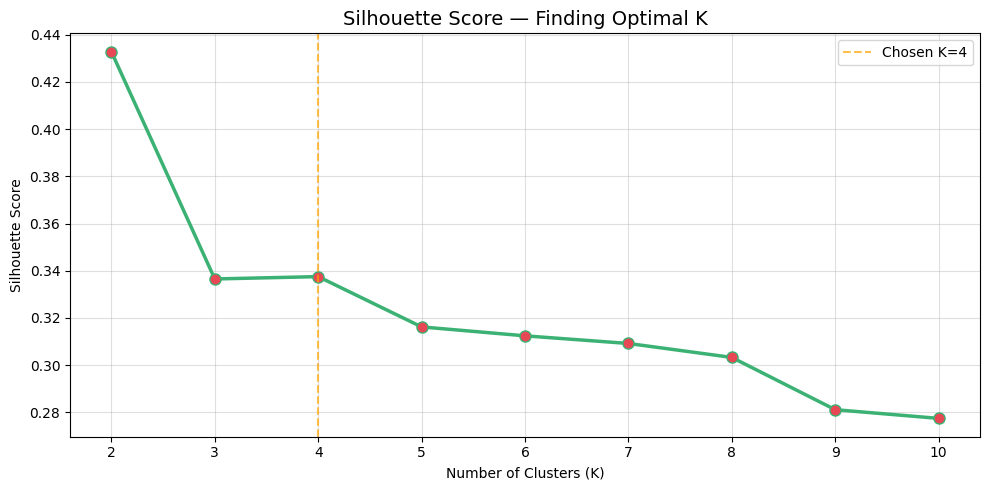

Plot saved!


In [7]:
plt.figure(figsize=(10, 5))
plt.plot(list(K_range2), silhouette_scores, marker='o', linewidth=2.5,
         color='#3BB273', markersize=8, markerfacecolor='#E84855')

plt.title('Silhouette Score — Finding Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(K_range2))
plt.grid(True, alpha=0.4)

plt.axvline(x=4, color='orange', linestyle='--', alpha=0.7, label='Chosen K=4')
plt.legend()

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/figures/silhouette_scores.png', dpi=150)
plt.show()
print("Plot saved!")

In [8]:
# Train final model
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

print("Model trained!")
print(f"\nCustomers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())
print(f"\nPercentage per cluster:")
print((rfm['Cluster'].value_counts(normalize=True).sort_index() * 100).round(1))

Model trained!

Customers per cluster:
Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

Percentage per cluster:
Cluster
0    16.4
1    37.4
2    19.3
3    26.9
Name: proportion, dtype: float64


In [9]:
profile = rfm.groupby('Cluster').agg(
    Customers  = ('Customer ID', 'count'),
    Recency    = ('Recency', 'mean'),
    Frequency  = ('Frequency', 'mean'),
    Monetary   = ('Monetary', 'mean')
).round(1)

print("=== CLUSTER PROFILES ===")
print(profile)

=== CLUSTER PROFILES ===
         Customers  Recency  Frequency  Monetary
Cluster                                         
0              713     12.2       13.8    8088.0
1             1622    181.5        1.3     341.0
2              837     17.7        2.2     557.3
3             1166     71.6        4.1    1801.8


In [10]:
cluster_names = {
    0: 'Champions',
    1: 'Lost Customers',
    2: 'New & Promising',
    3: 'At Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

print("Segments assigned!")
print(f"\nCustomers per segment:")
print(rfm['Segment'].value_counts())
print(f"\nSample:")
print(rfm.head(10))

Segments assigned!

Customers per segment:
Segment
Lost Customers     1622
At Risk            1166
New & Promising     837
Champions           713
Name: count, dtype: int64

Sample:
   Customer ID  Recency  Frequency  Monetary  Cluster          Segment
0        12346      326          1  77183.60        3          At Risk
1        12347        2          7   4310.00        0        Champions
2        12348       75          4   1797.24        3          At Risk
3        12349       19          1   1757.55        2  New & Promising
4        12350      310          1    334.40        1   Lost Customers
5        12352       36          8   2506.04        3          At Risk
6        12353      204          1     89.00        1   Lost Customers
7        12354      232          1   1079.40        1   Lost Customers
8        12355      214          1    459.40        1   Lost Customers
9        12356       23          3   2811.43        3          At Risk


In [11]:
rfm.to_csv(f'{PROCESSED}/rfm_segments.csv', index=False)

print("Saved!")
print(f"\nFinal file shape: {rfm.shape}")
print(f"Columns: {rfm.columns.tolist()}")

Saved!

Final file shape: (4338, 6)
Columns: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']


In [12]:
# ================================================
# CLUSTERING SUMMARY
# ================================================
# Method:       K-Means Clustering
# Features:     Recency, Frequency, Monetary (scaled)
# Optimal K:    4 (confirmed by Elbow + Silhouette)
#
# SEGMENTS:
# ┌─────────────────┬───────┬─────────┬───────────┬──────────┐
# │ Segment         │ Count │ Recency │ Frequency │ Monetary │
# ├─────────────────┼───────┼─────────┼───────────┼──────────┤
# │ Champions       │   713 │  12 days│  14 orders│  £8,088  │
# │ Lost Customers  │  1622 │ 182 days│   1 order │    £341  │
# │ New & Promising │   837 │  18 days│   2 orders│    £557  │
# │ At Risk         │  1166 │  72 days│   4 orders│  £1,802  │
# └─────────────────┴───────┴─────────┴───────────┴──────────┘
#
# Business Actions:
# Champions     → Reward, loyalty program, early access
# Lost          → Win-back campaign or write off
# New/Promising → Onboarding emails, first purchase offers
# At Risk       → Urgent re-engagement, discounts
# ================================================